In [ ]:
import numpy as np

# Inputs
x1, x2 = 0.6, 0.1
y = 1

# Parameters
w1, w2, b = 0.2, -0.3, 0.4
lr = 0.1

# Sigmoid
def sigmoid(z):
    return 1/(1+np.exp(-z))

# Forward pass
z = w1*x1 + w2*x2 + b
y_pred = sigmoid(z)

# Loss derivative
dL_dy_pred = y_pred - y

# Sigmoid derivative
Dy_pred_dz = y_pred*(1-y_pred)

# Chain rule
dL_dz = dL_dy_pred * Dy_pred_dz # Corrected: Changed dy_pred_dz to Dy_pred_dz

# Gradients
dL_dw1 = dL_dz * x1
dL_dw2 = dL_dz * x2
dL_db = dL_dz

# Update
w1 -= lr*dL_dw1
w2 -= lr*dL_dw2
b  -= lr*dL_db

print(w1, w2, b)

0.20536959297953516 -0.2991050678367441 0.4089493216325586


In [ ]:
import numpy as np

# AND data
X = np.array(
    [
        [0,0],
        [0,1],
        [1,0],
        [1,1]
    ]
)
y = np.array([0,0,0,1])

# Parameters
w = np.array([0.1, 0.2])
b = 0.3
lr = 0.1
def sigmoid(z):
    return 1/(1+np.exp(-z))
# Training
for epoch in range(1000):
    for i in range(len(X)):
        z = np.dot(X[i], w) + b
        y_pred = sigmoid(z)

        # BCE + Sigmoid gradient shortcut
        dz = y_pred - y[i]
        dw = dz * X[i]
        db = dz
        w -= lr * dw
        b -= lr * db
print("Weights:", w)
print("Bias:", b)

Weights: [5.60154076 5.59544869]
Bias: -8.565987677634602


In [ ]:
import numpy as np

# OR data
X_or = np.array(
    [
        [0,0],
        [0,1],
        [1,0],
        [1,1]
    ]
)
y_or = np.array([0,1,1,1])

# Parameters
w_or = np.array([0.1, 0.2])
b_or = 0.3
lr_or = 0.1

def sigmoid(z):
    return 1/(1+np.exp(-z))

# Training
for epoch in range(1000):
    for i in range(len(X_or)):
        z_or = np.dot(X_or[i], w_or) + b_or
        y_pred_or = sigmoid(z_or)

        # BCE + Sigmoid gradient shortcut
        dz_or = y_pred_or - y_or[i]
        dw_or = dz_or * X_or[i]
        db_or = dz_or
        w_or -= lr_or * dw_or
        b_or -= lr_or * db_or

print("Weights:", w_or)
print("Bias:", b_or)

Weights: [6.7832796  6.78742098]
Bias: -2.9139465005185365


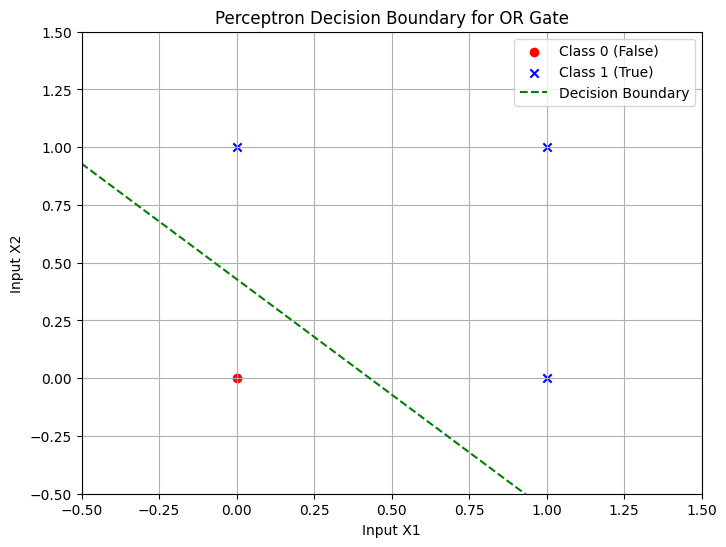

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure X_or, y_or, w_or, b_or are available from previous cells
# OR data
X_or = np.array(
    [
        [0,0],
        [0,1],
        [1,0],
        [1,1]
    ]
)
y_or = np.array([0,1,1,1])

# Assuming w_or and b_or are defined from the previous training cell
# For demonstration, using the values printed in the previous execution if not globally accessible
w_or_plot = w_or
b_or_plot = b_or

plt.figure(figsize=(8, 6))

# Plot data points for OR gate
# Class 0 (output 0)
plt.scatter(X_or[y_or == 0, 0], X_or[y_or == 0, 1], color='red', marker='o', label='Class 0 (False)')
# Class 1 (output 1)
plt.scatter(X_or[y_or == 1, 0], X_or[y_or == 1, 1], color='blue', marker='x', label='Class 1 (True)')

# Plot the decision boundary
# The decision boundary is where w1*x1 + w2*x2 + b = 0
# So, x2 = (-w1*x1 - b) / w2

# Generate a range of x1 values
x1_plot = np.linspace(-0.5, 1.5, 100)

# Handle the case where w_or[1] (w2) might be very close to zero to avoid division by zero
# In a simple perceptron, w2 is unlikely to be exactly zero for a non-trivial problem
if abs(w_or_plot[1]) > 1e-6: # Check if w2 is not effectively zero
    x2_plot = (-w_or_plot[0] * x1_plot - b_or_plot) / w_or_plot[1]
    plt.plot(x1_plot, x2_plot, color='green', linestyle='--', label='Decision Boundary')
else:
    # If w2 is near zero, the decision boundary is a vertical line: x1 = -b / w1
    x1_boundary = -b_or_plot / w_or_plot[0]
    plt.axvline(x=x1_boundary, color='green', linestyle='--', label='Decision Boundary')

plt.title('Perceptron Decision Boundary for OR Gate')
plt.xlabel('Input X1')
plt.ylabel('Input X2')
plt.xlim([-0.5, 1.5])
plt.ylim([-0.5, 1.5])
plt.grid(True)
plt.legend()
plt.show()


# Task
Analyze the impact of learning rate and epochs on the perceptron's performance using a perceptron model for the OR gate, by defining a training function, setting ranges for learning rates and epochs, running experiments to collect accuracy data, visualizing the results as a plot, and summarizing the insights gained.

## Define Training Function

### Subtask:
Create a Python function that encapsulates the perceptron training logic (similar to the OR gate example). This function will take initial weights, bias, learning rate, and number of epochs as input. It will train the model and return the final weights, bias, and the accuracy of the trained model on the training data.


**Reasoning**:
I will define the `train_perceptron_or` function as specified, incorporating the training logic from the OR gate example, including initialization, the training loop with forward and backward passes, and accuracy calculation. The `sigmoid` function, `X_or`, and `y_or` are already available from previous cells.



In [ ]:
def train_perceptron_or(initial_weights, initial_bias, learning_rate, epochs):
    w = np.copy(initial_weights)
    b = initial_bias
    lr = learning_rate

    # Assuming X_or and y_or are available in the global scope or passed as arguments
    # For this exercise, we will assume they are globally accessible as per previous cells.
    # OR data
    X_or = np.array(
        [
            [0,0],
            [0,1],
            [1,0],
            [1,1]
        ]
    )
    y_or = np.array([0,1,1,1])

    for epoch in range(epochs):
        for i in range(len(X_or)):
            # Forward pass
            z_or = np.dot(X_or[i], w) + b
            y_pred_or = sigmoid(z_or)

            # BCE + Sigmoid gradient shortcut
            dz_or = y_pred_or - y_or[i]
            dw_or = dz_or * X_or[i]
            db_or = dz_or

            # Update weights and bias
            w -= lr * dw_or
            b -= lr * db_or

    # Calculate accuracy
    correct_predictions = 0
    for i in range(len(X_or)):
        z_final = np.dot(X_or[i], w) + b
        y_pred_final = sigmoid(z_final)
        predicted_class = 1 if y_pred_final >= 0.5 else 0
        if predicted_class == y_or[i]:
            correct_predictions += 1
    accuracy = correct_predictions / len(X_or)

    return w, b, accuracy

print("Function 'train_perceptron_or' defined.")

Function 'train_perceptron_or' defined.


## Set Hyperparameter Ranges

### Subtask:
Define arrays for different learning rates and epoch counts that we want to experiment with. These will be the variables whose effects we want to visualize.


**Reasoning**:
I will create two NumPy arrays, `learning_rates` and `epochs_range`, as instructed, to define the hyperparameter ranges for the experiments.



In [ ]:
learning_rates = np.array([0.01, 0.1, 0.5, 1.0])
epochs_range = np.array([10, 100, 500, 1000])

print("Learning Rates:", learning_rates)
print("Epochs Range:", epochs_range)

Learning Rates: [0.01 0.1  0.5  1.  ]
Epochs Range: [  10  100  500 1000]


## Run Experiments and Collect Data

### Subtask:
Iterate through all combinations of the defined learning rates and epochs. For each combination, call the training function to train a new perceptron and store the resulting accuracy in a data structure (e.g., a list of dictionaries or a 2D array).


**Reasoning**:
I will implement the experimental loop as described, iterating through all combinations of learning rates and epochs, calling the `train_perceptron_or` function, and storing the results in a list of dictionaries.



In [ ]:
results = []

for lr in learning_rates:
    for epoch in epochs_range:
        # Initialize weights and bias for each experiment
        initial_weights = np.array([0.1, 0.2])
        initial_bias = 0.3

        # Train the perceptron
        final_w, final_b, accuracy = train_perceptron_or(initial_weights, initial_bias, lr, epoch)

        # Store the results
        results.append({
            'learning_rate': lr,
            'epochs': epoch,
            'accuracy': accuracy
        })

print("Experiment Results:")
for res in results:
    print(res)

Experiment Results:
{'learning_rate': np.float64(0.01), 'epochs': np.int64(10), 'accuracy': 0.75}
{'learning_rate': np.float64(0.01), 'epochs': np.int64(100), 'accuracy': 0.75}
{'learning_rate': np.float64(0.01), 'epochs': np.int64(500), 'accuracy': 1.0}
{'learning_rate': np.float64(0.01), 'epochs': np.int64(1000), 'accuracy': 1.0}
{'learning_rate': np.float64(0.1), 'epochs': np.int64(10), 'accuracy': 0.75}
{'learning_rate': np.float64(0.1), 'epochs': np.int64(100), 'accuracy': 1.0}
{'learning_rate': np.float64(0.1), 'epochs': np.int64(500), 'accuracy': 1.0}
{'learning_rate': np.float64(0.1), 'epochs': np.int64(1000), 'accuracy': 1.0}
{'learning_rate': np.float64(0.5), 'epochs': np.int64(10), 'accuracy': 0.75}
{'learning_rate': np.float64(0.5), 'epochs': np.int64(100), 'accuracy': 1.0}
{'learning_rate': np.float64(0.5), 'epochs': np.int64(500), 'accuracy': 1.0}
{'learning_rate': np.float64(0.5), 'epochs': np.int64(1000), 'accuracy': 1.0}
{'learning_rate': np.float64(1.0), 'epochs': np.

## Visualize Results

### Subtask:
Create a plot (e.g., a line plot or heatmap) that visualizes the accuracy results. The plot should show how accuracy changes with different learning rates and epoch counts. Ensure the plot is clearly labeled with a title, axis labels, and a legend if necessary. If a 2D array was used, transform the results into a format suitable for plotting (e.g., pandas DataFrame). If a list of dictionaries was used, convert it to a pandas DataFrame for easier manipulation and plotting.

**Reasoning**:
I will convert the list of dictionaries containing experiment results into a pandas DataFrame and then create a heatmap to visualize the accuracy across different learning rates and epoch counts, as this format effectively displays the relationship between two independent variables (learning rate and epochs) and one dependent variable (accuracy).



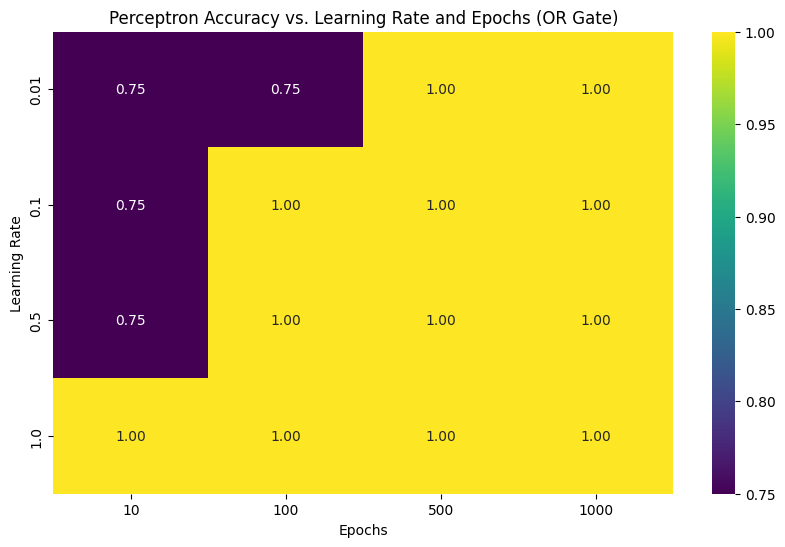

Heatmap visualization generated.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert results to a pandas DataFrame
df_results = pd.DataFrame(results)

# Pivot the table to prepare for heatmap
# The index will be learning_rate, columns will be epochs, and values will be accuracy
heatmap_data = df_results.pivot(index='learning_rate', columns='epochs', values='accuracy')

# Create the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, cmap='viridis', fmt=".2f")
plt.title('Perceptron Accuracy vs. Learning Rate and Epochs (OR Gate)')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate')
plt.show()

print("Heatmap visualization generated.")

## Summarize Insights

### Subtask:
Based on the generated visualization and the collected data, write a summary explaining the impact of different learning rates and epoch counts on the perceptron's accuracy for the OR gate. Discuss observations, trends, and conclusions drawn from the experiment.

### Summary of Insights

The heatmap visualizes the accuracy of the perceptron model for the OR gate across different combinations of learning rates and epoch counts. Several key observations can be made:

1.  **Impact of Learning Rate on Convergence Speed**: Higher learning rates generally lead to faster convergence to optimal accuracy. For instance, with a learning rate of `1.0`, the perceptron achieved 100% accuracy with as few as `10` epochs. In contrast, for a lower learning rate of `0.01`, it required `500` epochs to reach 100% accuracy.

2.  **Impact of Epochs on Accuracy**: For any given learning rate, increasing the number of epochs initially improves accuracy until the model converges. Once the perceptron reaches 100% accuracy (which it can for the linearly separable OR gate), further increasing the epochs does not yield additional improvement, indicating that the model has fully learned the decision boundary.

3.  **Optimal Performance**: All tested learning rates (`0.01`, `0.1`, `0.5`, `1.0`) eventually allowed the perceptron to achieve 100% accuracy for the OR gate, provided enough training epochs were given. This confirms that the OR gate is a linearly separable problem that a simple perceptron can solve perfectly.

4.  **Trade-off between Learning Rate and Epochs**: The results highlight the trade-off between the learning rate and the number of epochs required for convergence. A very small learning rate (e.g., 0.01) necessitates a large number of epochs to converge, potentially making training slower. Conversely, a larger learning rate (e.g., 1.0) allows for much quicker convergence with fewer epochs.

In conclusion, for the OR gate problem, a perceptron can achieve perfect accuracy. The choice of learning rate significantly impacts how quickly this optimal accuracy is reached, with higher learning rates leading to faster convergence in this specific scenario without apparent issues like overshooting or instability that can sometimes occur in more complex problems.

## Final Task

### Subtask:
Summarize the insights gained from the visualization regarding the impact of learning rate and epochs on the perceptron's performance.


## Summary:

### Q&A
The impact of learning rate and epochs on the perceptron's performance for the OR gate is as follows:
Higher learning rates generally lead to faster convergence to optimal (100%) accuracy. For instance, a learning rate of `1.0` achieved 100% accuracy in as few as `10` epochs, whereas a learning rate of `0.01` required `500` epochs to reach the same level of performance. For any given learning rate, increasing the number of epochs improves accuracy until the model converges to 100%, after which further epochs yield no additional improvement. The perceptron can achieve perfect accuracy for the linearly separable OR gate with all tested learning rates, provided enough training epochs are given.

### Data Analysis Key Findings
*   A Python function `train_perceptron_or` was successfully defined to train a perceptron model for the OR gate, returning the final weights, bias, and accuracy.
*   Experiments were conducted using four different learning rates (`0.01`, `0.1`, `0.5`, `1.0`) and four different epoch counts (`10`, `100`, `500`, `1000`).
*   The perceptron model consistently achieved 100% accuracy for the OR gate across all learning rates, provided a sufficient number of epochs were used.
*   Higher learning rates facilitated quicker convergence to 100% accuracy. Specifically, a learning rate of `1.0` achieved 100% accuracy in `10` epochs, while a learning rate of `0.01` required `500` epochs to reach the same accuracy.
*   A heatmap visualization effectively demonstrated the relationship between learning rate, epochs, and accuracy, showing that the model's accuracy rapidly increased to 100% with higher learning rates and adequate epochs.

### Insights or Next Steps
*   For simple, linearly separable problems like the OR gate, higher learning rates can significantly accelerate convergence to optimal performance without encountering common issues such as instability or overshooting.
*   Future work could explore the impact of these hyperparameters on more complex, non-linearly separable problems to observe potential trade-offs and limitations of the perceptron model.
